# Missile Interference Test

## Problem Statement

Engineers and operators need to quickly model and analyze a telemetry link from a missile launch and to determine how various settings on a radar
will affect its ability to track a missile. You are launching a test missile from a launch pad located on the Pacific Coast of the United States.
The missile will transmit telemetry data to a communications system on board a ship anchored off the coast. The missile's telemetry data will be
transmitted on an S-band frequency, which is close to a frequency used by multiple high-power satellite digital audio radio service (SDARS)
satellites. Phase one of your test will determine if the satellites, which provide XM radio service, will interfere with ship's ability to receive
the test missile telemetry data. Phase two of your test will determine for how long a shipborne radar system can detect and track the missile
during its flight. A custom radar cross section and a radar antenna pattern file are required for your analysis.

This example is based on [this](https://help.agi.com/stk/Content/training/Missile_Test_XM_Interference.htm) tutorial.

## Launch a new STK instance

In [1]:
from ansys.stk.core.stkengine import STKEngine


stk = STKEngine.start_application(no_graphics=False)
print(f"Using {stk.version}")

Using STK Engine v13.1.0


## Create a new scenario

In [2]:
root = stk.new_object_root()
root.new_scenario("CommRadar_MissileTest_Interference")

Once the scenario is created, you can view a 3D graphics window by running:

RFBOutputContext()

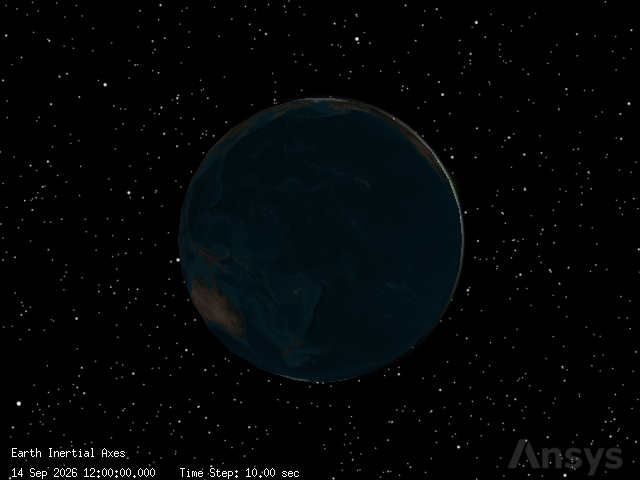

In [3]:
from ansys.stk.core.experimental.jupyterwidgets import GlobeWidget


globe_widget = GlobeWidget(root, 640, 480)
globe_widget.camera.position = [0, 0, 0]
globe_widget.show()

Once the scenario is created, you can view a 2D graphics window by running:

RFBOutputContext()

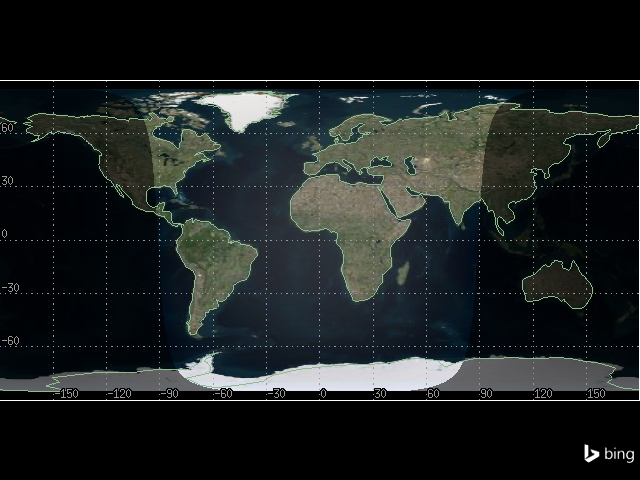

In [4]:
from ansys.stk.core.experimental.jupyterwidgets import MapWidget


map_widget = MapWidget(root, 640, 480)
map_widget.show()

## Set the scenario time period

In [5]:
scenario = root.current_scenario
scenario.set_time_period("10 June 2026 16:00:00.000", "10 June 2026 16:35:00.000")
root.rewind()

## Model the test missile

Insert a new Missile object

In [6]:
from ansys.stk.core.stkobjects import Missile, STKObjectType


test_missile = scenario.children.new(STKObjectType.MISSILE, "test_missile")

First, set the units properly. Setting units proactively is a great practice!

In [7]:
root.units_preferences.item("Latitude").set_current_unit("deg")
root.units_preferences.item("Longitude").set_current_unit("deg")
root.units_preferences.item("Distance").set_current_unit("km")

Next, design the missile's trajectory:

In [8]:
from ansys.stk.core.stkobjects import (
    IPropagator,
    PropagatorType,
    VehicleImpactLocationPoint,
    VehicleLaunchControl,
)


test_missile.set_trajectory_type(PropagatorType.BALLISTIC)
trajectory = test_missile.trajectory
root.units_preferences.set_current_unit("DateFormat", "EpSec")
trajectory.ephemeris_interval.set_explicit_interval(0, 0)

Next, set the launch parameters:

In [9]:
trajectory.launch.latitude = 34.7556
trajectory.launch.longitude = -120.6223
trajectory.launch.altitude = 0.0024385

Then, set the impact parameters:

In [10]:
impact_location = trajectory.impact_location

impact_location.impact.latitude = 10
impact_location.impact.longitude = 173
impact_location.set_launch_control_type(VehicleLaunchControl.FIXED_DELTA_V)
impact_location.launch_control.delta_v = 6.90194
impact_location.impact.altitude = 0.0024385

Lastly, propagate:

In [11]:
trajectory.propagate()

We can now view the test missile's trajectory:

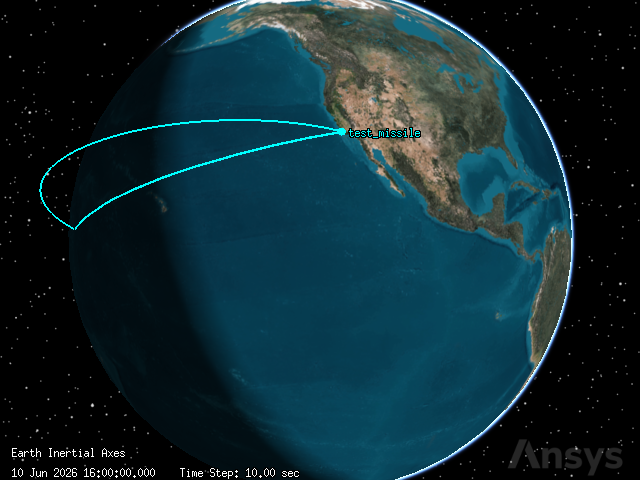

In [12]:
globe_widget.camera.position = [
    19252.274451116944,
    4639.005171788969,
    5592.340350242526,
]
globe_widget.show()

## Generate an Altitude vs Ground Range report

Use a data provider to generate the report:

In [13]:
provider = test_missile.data_providers.item("Ground Range").group.item("Fixed")

Then, set the time step. This is set in seconds.

In [14]:
time_step = 60

Now, generate the report

In [15]:
ground_range_report = provider.execute(
    scenario.start_time, scenario.stop_time, time_step
).data_sets.to_pandas_dataframe()
ground_range_report[["time", "ground range", "alt"]]

,time,ground range,alt
0,0.000000,0.000000,0.002439
1,60.000000,301.676840,260.064691
2,120.000000,583.118013,499.216861
3,180.000000,847.852529,718.512810
4,240.000000,1098.671575,918.858608
5,300.000000,1337.823957,1101.034496
6,360.000000,1567.152601,1265.712771
7,420.000000,1788.192134,1413.472302
8,480.000000,2002.240180,1544.810324
9,540.000000,2210.410493,1660.152024


## Model the test missile's transmitter

Insert a Transmitter object

In [16]:
from ansys.stk.core.stkobjects import Transmitter


missile_transmitter = test_missile.children.new(STKObjectType.TRANSMITTER, "Missile_Tx")

Use a Medium Transmitter model

In [17]:
missile_transmitter.model_component_linking.set_component("Medium Transmitter Model")
transmitter_model = missile_transmitter.model_component_linking.component

Set the transmitter properties

In [18]:
transmitter_model.frequency = 2.31
transmitter_model.power = 19.03
transmitter_model.antenna_gain = -0.57
transmitter_model.data_rate = 2.048

Set the transmitter modulation options

In [19]:
transmitter_model.set_modulator("BPSK")
transmitter_model.modulator.enable_signal_psd = True

## Model the ship

Insert a new Ship object

In [20]:
from ansys.stk.core.stkobjects import Ship


ship = scenario.children.new(STKObjectType.SHIP, "Ship")

# Define the ship's route options

In the tutorial, the ship is defined to be stationary. First, set the propogator type to great arc:

In [21]:
from ansys.stk.core.stkobjects import (
    IGreatArcVehicle,
    PropagatorGreatArc,
    PropagatorType,
    VehicleWaypointComputationMethod,
)


IGreatArcVehicle(ship).set_route_type(PropagatorType.GREAT_ARC)

Second, set the altitude reference:

In [22]:
from ansys.stk.core.stkobjects import VehicleAltitudeReference


ship.route.set_altitude_reference_type(VehicleAltitudeReference.WGS84)

Now, we can propagate. Set the latitude, longitude, and the timing.

In [23]:
PropagatorGreatArc(IGreatArcVehicle(ship).route).set_points_specify_time_and_propagate(
    [
        [scenario.start_time, 34.196, -120, 0, 0],
        [scenario.stop_time, 34.196, -120, 0, 0],
    ]
)

Insert a Sensor Object

In [24]:
from ansys.stk.core.stkobjects import Sensor, SensorPattern, SensorSimpleConicPattern


antenna_motor = ship.children.new(STKObjectType.SENSOR, "Antenna_Motor")

Define the sensor's cone half angle

In [25]:
antenna_motor.set_pattern_type(SensorPattern.SIMPLE_CONIC)
SensorSimpleConicPattern(antenna_motor.pattern).cone_angle = 5

Set the antenna motor's location type to fixed.

In [26]:
from ansys.stk.core.stkobjects import SensorLocation


antenna_motor.set_location_type(SensorLocation.FIXED)

After the location type is set to fixed, the location is editable using cartesian coordinates.

In [27]:
root.units_preferences.item("Distance").set_current_unit("ft")
antenna_motor.location_data.assign_cartesian(75, 0, 75)

Target the test missile.

In [28]:
from ansys.stk.core.stkobjects import BoresightType, TrackMode


antenna_motor.common_tasks.set_pointing_targeted_tracking(
    TrackMode.RECEIVE, BoresightType.ROTATE, "Missile/test_missile"
)

View the targeted antenna is the 3D graphics window

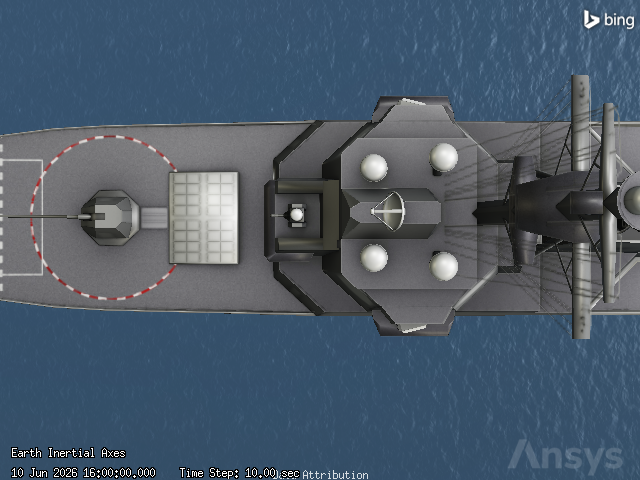

In [29]:
globe_widget.camera.position = [
    16443720.539118323,
    5550468.64120438,
    11651969.751643106,
]
globe_widget.show()

## Model the test ship's receiver

Insert a Receiver object that is attached to the "antenna motor" sensor.

In [30]:
from ansys.stk.core.stkobjects import Receiver


ship_receiver = antenna_motor.children.new(STKObjectType.RECEIVER, "Ship_Rx")

Use a Complex Receiver model. Once this is set we can edit its properties.

In [31]:
ship_receiver.model_component_linking.set_component("Complex Receiver Model")
receiver_model = ship_receiver.model_component_linking.component

Now we can set the receiver to automatically track frequency.

In [32]:
receiver_model.track_frequency_automatically = True

Define the receiver's antenna specifications. First, set the antenna model to helix.

In [33]:
from ansys.stk.core.stkobjects import AntennaModelHelix, IAntennaModel


receiver_model.antenna_control.embedded_model_component_linking.set_component("Helix")
helix_model = receiver_model.antenna_control.embedded_model_component_linking.component

Once the antenna model is set to "helix," we can edit these properties:

In [34]:
IAntennaModel(helix_model).design_frequency = 2.5
helix_model.diameter = 0.9
helix_model.efficiency = 55
helix_model.turn_spacing = 0.001
helix_model.number_of_turns = 3
helix_model.backlobe_gain = -30

Let's now visualize the receiver's antenna pattern. First define a volume variable.

In [35]:
from ansys.stk.core.stkobjects import AntennaVolumeGraphics


volume = ship_receiver.graphics_3d.volume

Before anything else, we must set show volume to "true." Once this is set, we can edit the rest of the properties.

In [36]:
volume.show = True
volume.gain_scale = 0.5

We are now able to edit the pattern properties. These can be set all together at once:

In [37]:
volume.set_resolution(
    azimuth_start=-180,
    azimuth_stop=180,
    azimuth_resolution=1,
    elevation_start=0,
    elevation_stop=90,
    elevation_resolution=1,
)

Add gain coloring

In [38]:
from ansys.stk.core.stkobjects import FigureOfMeritGraphics2DColorMethod


volume.color_method = FigureOfMeritGraphics2DColorMethod.EXPLICIT
volume.relative_to_maximum = True

Next, add levels to the shading:

In [39]:
levels = volume.levels
levels.clear()

for gain in range(-70, 1, 10):
    level = levels.add(gain)

## Analyze the telemetry downlink's link budget

Create a simple link budget to calculate the bit error rate (BER), which reflects of how often errors occur in the transmission of digital data. You can compute a simple link budget using the Access tool. For the purposes of this analysis, a Bit Error Rate of 1.000000e-09 or lower is acceptable.

First, create and compute an access between the receiver and transmitter:

In [40]:
from pandas import DataFrame

from ansys.stk.core.stkobjects import Access, ISTKObject


access = ISTKObject(ship_receiver).get_access_to_object(missile_transmitter)
access.compute_access()

After computing the access, we can use data providers to retrieve the link information data.

In [41]:
provider = access.data_providers.item("Link Information")

Finally, create and generate the link budget report.

In [42]:
link_budget_report = provider.execute(
    scenario.start_time, scenario.stop_time, time_step
).data_sets.to_pandas_dataframe()

Focus on the ber column:

In [43]:
link_budget_report[["ber"]]

,ber
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.000001
9,0.00001


## Insert the interfering satellites

Get the STK database location using Connect

In [44]:
from pathlib import Path

from ansys.stk.core.stkobjects import ExecuteCommandResult


result = root.execute_command("GetDirectory / Database Satellite")
satellite_data_dir = result[0]
file_location = '"' + str(Path(satellite_data_dir) / Path(r"stkAllTLE.sd")) + '"'

Import object from database using Connect

In [45]:
command = f"ImportFromDB * Satellite {file_location} Propagate On CommonName SXM-8"
root.execute_command(command)

command = f"ImportFromDB * Satellite {file_location} Propagate On CommonName SXM-9"
root.execute_command(command)

command = f"ImportFromDB * Satellite {file_location} Propagate On CommonName SXM-10"
root.execute_command(command)

Assign the satellites to variables:

In [46]:
from ansys.stk.core.stkobjects import Satellite


sxm_8 = scenario.children.item("SXM-8_48838")
sxm_9 = scenario.children.item("SXM-9_62259")
sxm_10 = scenario.children.item("SXM-10_64290")

## Model the interfering satellites' transmitters

In [47]:
from ansys.stk.core.stkobjects import TransmitterModelMedium


transmitters = []

for satellite in [sxm_8, sxm_9, sxm_10]:
    transmitter = ISTKObject(satellite).children.new(
        STKObjectType.TRANSMITTER, "Transmitter"
    )

    transmitter.model_component_linking.set_component("Medium Transmitter Model")

    transmitter_model = TransmitterModelMedium(
        transmitter.model_component_linking.component
    )

    transmitter_model.frequency = 2.3347
    transmitter_model.power = 41.2385
    transmitter_model.data_rate = 0.048
    transmitter_model.antenna_gain = 40

    transmitter_model.set_modulator("QPSK")
    transmitter_model.modulator.scale_bandwidth_automatically = True

    transmitters.append(transmitter)

Assign the satellite transmitters to the existing satellite variables:

In [48]:
sxm_8_transmitter = transmitters[0]
sxm_9_transmitter = transmitters[1]
sxm_10_transmitter = transmitters[2]

## Check for interference

There are several methods through which you can determine the impact of interference on a system. For less complex systems, like the one in this scenario, you can compute interference effects directly in a Receiver object.

Create an interference variable. Use this to modify the interference on the receiver.

In [49]:
from ansys.stk.core.stkobjects import ISTKObject, RFInterference


interference = RFInterference(
    ship_receiver.model_component_linking.component.interference
)

We have to enable interference before we are able to edit the interference sources:

In [50]:
interference.enabled = True

Only now are we able to add the interference sources.

In [51]:
interference.emitters.add(sxm_8_transmitter.path)
interference.emitters.add(sxm_9_transmitter.path)
interference.emitters.add(sxm_10_transmitter.path)

Determine the impact of interference with a Link Budget - Interference report. First, compute the access.

In [52]:
access = ISTKObject(ship_receiver).get_access_to_object(missile_transmitter)
access.compute_access()

Next, use data providers to retrieve the link information data.

In [53]:
provider = access.data_providers.item("Link Information")

Finally, generate the link budget report.

In [54]:
link_budget_report = provider.execute(
    scenario.start_time, scenario.stop_time, time_step
).data_sets.to_pandas_dataframe()

Focus on the ber and ber+i columns:

In [55]:
link_budget_report[["ber", "ber+i"]]

,ber,ber+i
0,0.0,0.0
1,0.0,0.053852
2,0.0,0.227621
3,0.0,0.302732
4,0.0,0.339659
5,0.0,0.360267
6,0.0,0.372342
7,0.0,0.37918
8,0.000001,0.382307
9,0.00001,0.382398


## Mitigate interference with a spectrum filter

To use a filter, we have to enable it:

In [56]:
receiver_model.enable_filter = True

We are now able to set the filter type. Set it to Butterworth for this scenario.

In [57]:
receiver_model.filter_component_linking.set_component("Butterworth")
ship_receiver_filter = receiver_model.filter_component_linking.component

Then, set the Butterworth filter properties:

In [58]:
ship_receiver_filter.upper_bandwidth_limit = 20
ship_receiver_filter.lower_bandwidth_limit = -20
ship_receiver_filter.cut_off_frequency = 5
ship_receiver_filter.order = 4

Recompute the Link Budget - Interference report. The access must be refreshed first.

In [59]:
access = ISTKObject(ship_receiver).get_access_to_object(missile_transmitter)
access.compute_access()

Then retrieve the link information data:

In [60]:
provider = access.data_providers.item("Link Information")

Generate the link information report.

In [61]:
link_budget_report = provider.execute(
    scenario.start_time, scenario.stop_time, time_step
).data_sets.to_pandas_dataframe()

Focus on the ber and ber+i columns:

In [62]:
link_budget_report[["ber", "ber+i"]]

,ber,ber+i
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.000002,0.000002
9,0.000015,0.000015


## Model the ship's radar

First, insert a radar object

In [63]:
from ansys.stk.core.stkobjects import Radar


ship_radar = ship.children.new(STKObjectType.RADAR, "Ship_Radar")

Next, set the radar system to monostatic.

In [64]:
ship_radar.model_component_linking.set_component("Monostatic")
monostatic_radar = ship_radar.model_component_linking.component

Once the radar system is set to monostatic, we can specify the mode. Select search track.

In [65]:
monostatic_radar.mode_component_linking.set_component("Search Track")
monostatic_search_track_radar = monostatic_radar.mode_component_linking.component

Only after setting the mode to search track can we modify the pulse width. This property is located in the pulse definition sub-tab of the waveform sub-tab.

In [66]:
monostatic_search_track_radar.waveform.pulse_definition.pulse_width = 8.8e-7

Then, set the goal signal-to-noise ratio. This is also located in the pulse definition sub-tab of the waveform sub-tab.

In [67]:
monostatic_search_track_radar.waveform.pulse_integration.snr = 20

Configure the radar's antenna model to use an external pattern.

In [68]:
from ansys.stk.core.stkobjects import AntennaControl, AntennaModelExternal


antenna_control = ship_radar.model_component_linking.component.antenna_control
antenna_control.embedded_model_component_linking.set_component(
    "External Antenna Pattern"
)

external_model = AntennaModelExternal(
    antenna_control.embedded_model_component_linking.component
)

Once an external pattern is selected, set the design frequency:

In [69]:
external_model.design_frequency = 2.8

Then, specify the file from which the pattern will be provided.

In [70]:
import pathlib


install_dir = root.execute_command("GetDirectory / STKHome")[0]
external_model.filename = str(
    pathlib.Path(install_dir)
    / "Data"
    / "Resources"
    / "stktraining"
    / "samples"
    / "ASR9Low.pattern"
)

Set the radar antenna's orientation. These properties are located in the orientation sub-tab of the antenna tab.

In [71]:
root.units_preferences.item("SmallDistance").set_current_unit("ft")

antenna_control.embedded_model_orientation.position_offset.set(37, 0, 120)

Create a radar transmitter:

In [72]:
from ansys.stk.core.stkobjects import RadarFrequencySpecificationType, RadarReceiver


radar_transmitter = ship_radar.model_component_linking.component.transmitter

Set the radar transmitter specifications. First, select frequency as the independent property. Wavelength will be dependent on frequency.

In [73]:
radar_transmitter.frequency_specification = RadarFrequencySpecificationType.FREQUENCY

radar_transmitter.frequency = 2.8

Set the power of the radar transmitter. This does not depend on frequency or wavelength.

In [74]:
radar_transmitter.power = 100.414

Create a radar receiver:

In [75]:
radar_receiver = ship_radar.model_component_linking.component.receiver

Adjust the radar receiver LNA gain

In [76]:
radar_receiver.lna_gain = 25

## Define the missile's radar cross section

The Radar capability enables you to specify an important property of a potential radar target: its radar cross section (RCS). You can define the missile's RCS using an external RCS file. External RCS files can contain real-valued pattern data or complex-valued pattern data.

First, the missile must not inherit its cross section. We will specify it ourselves. It is now editable.

In [77]:
test_missile.radar_cross_section.inherit = False

Create a rcs band variable to manage the cross section properties:

In [78]:
from ansys.stk.core.stkobjects import (
    RadarCrossSectionComputeStrategyExternalFile,
    RadarCrossSectionFrequencyBand,
)


rcs_band = test_missile.radar_cross_section.model_component_linking.component.frequency_bands.item(
    0
)

Select an external file for the radar cross section.

In [79]:
rcs_band.set_compute_strategy("External File")

external_file_compute_strategy = rcs_band.compute_strategy
external_file_compute_strategy.filename = str(
    pathlib.Path(install_dir)
    / "Data"
    / "Resources"
    / "stktraining"
    / "samples"
    / "Basic_missile_mono.rcs"
)

## Compute access

Determine if the ship's radar can track the test missile. Refresh the access variable:

In [80]:
access = ISTKObject(ship_radar).get_access_to_object(test_missile)
access.compute_access()

## Create a custom report

Create a custom report style that shows azimuth-elevation-range (AER) and Radar Search/Track data. First, we will generate the AER Data portion of the report.

In [81]:
provider = access.data_providers.item("AER Data").group.item("BodyFixed")
aer_and_search_track_data = provider.execute(
    scenario.start_time, scenario.stop_time, time_step
).data_sets.to_pandas_dataframe()
print(aer_and_search_track_data[["time", "azimuth", "elevation", "range"]])

          time             azimuth             elevation               range
0     0.068662  -47.33435997690291  -0.19276471290045324  277499.68702389224
1         60.0  -2.278785030710994    34.067636249985355    1462814.02656295
2        120.0   2.637287438600781    34.305712102262504  2708711.7986098365
3        180.0   4.366064376252702     33.09089860338797  3896635.8925933205
4        240.0     5.1966484986581     31.52785544269757   5026421.219034072
5        300.0   5.651390966273694    29.833384453985886   6101062.783855856
6        360.0  5.9140062215640965    28.075614790646533   7123754.095134587
7        420.0   6.065621002107361    26.280807621897182  8097502.7277088445
8        480.0   6.147579911346308    24.459870205420977    9025068.15801134
9        540.0  6.1831565878512755     22.61707804832553    9908977.02534137
10       600.0   6.186450005446279    20.753497348091905  10751553.923284285
11       660.0   6.166496954712688    18.868514539739248   11554945.44885367

Second, we will generate the Radar SearchTrack portion of the report.

In [82]:
root.units_preferences.item("Distance").set_current_unit("km")

provider = access.data_providers.item("Radar SearchTrack")
aer_and_search_track_data = provider.execute(
    scenario.start_time, scenario.stop_time, time_step
).data_sets.to_pandas_dataframe()
print(
    aer_and_search_track_data[
        ["s/t integrated snr", "s/t integrated pdet", "s/t pulses integrated"]
    ]
)

    s/t integrated snr  s/t integrated pdet  s/t pulses integrated
0            22.576748             1.000000                    2.0
1            -5.494893             0.000105                  512.0
2           -16.636145             0.000101                  512.0
3           -21.211116             0.000100                  512.0
4           -23.659155             0.000100                  512.0
5           -24.981974             0.000100                  512.0
6           -25.834754             0.000100                  512.0
7           -27.150925             0.000100                  512.0
8           -28.248083             0.000100                  512.0
9           -30.037316             0.000100                  512.0
10          -32.302380             0.000100                  512.0
11          -33.878631             0.000100                  512.0
12          -35.741058             0.000100                  512.0
13          -35.864041             0.000100                  5

Third, we will generate the Radar RCS portion of the report.

In [83]:
provider = access.data_providers.item("Radar RCS")
aer_and_search_track_data = provider.execute(
    scenario.start_time, scenario.stop_time, time_step
).data_sets.to_pandas_dataframe()
print(aer_and_search_track_data[["rcs"]])

                   rcs
0     21.5498925193463
1    23.80801654878749
2    23.79895484286079
3   23.691431798714746
4    23.52711259802114
5    23.30253099730713
6    23.00502279045346
7   22.635415755390376
8   22.185178876046486
9   21.643958048109162
10  21.004639111379376
11   20.25682073179582
12  19.403254769659824
13   18.42415189631041
14   17.33665224948085
15  16.114323373833987
16  14.793766844632286
17  13.338317492966166
18  11.803556351357258
19  10.158098068570427
20   8.423157515326128
21  7.8536737655751265
